In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import glob

input_path = '/content/drive/MyDrive/SC_Dataset'
df = pd.read_csv(os.path.join(input_path, 'HAM10000_metadata.csv'))

all_images = glob.glob(input_path + '/HAM10000_images_part_*/*.jpg')
image_path_map = {}
for p in all_images:
    image_id = p.split('/')[-1].replace('.jpg', '')
    image_path_map[image_id] = p

df['path'] = df['image_id'].map(image_path_map)
df = df[['lesion_id', 'image_id', 'dx', 'path']]

print(f"Total images : {len(df)}")
print(f"Missing paths: {df['path'].isna().sum()}")
print(df['dx'].value_counts())

Total images : 10015
Missing paths: 0
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

lesions = df['lesion_id'].unique()
train_lesions, temp_lesions = train_test_split(
    lesions, test_size=0.3, random_state=42
)
val_lesions, test_lesions = train_test_split(
    temp_lesions, test_size=0.5, random_state=42
)

train_df = df[df['lesion_id'].isin(train_lesions)]
val_df   = df[df['lesion_id'].isin(val_lesions)]
test_df  = df[df['lesion_id'].isin(test_lesions)]

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

print("\nTrain class distribution:")
print(train_df['dx'].value_counts())
print("\nVal class distribution:")
print(val_df['dx'].value_counts())
print("\nTest class distribution:")
print(test_df['dx'].value_counts())

Train : 6987
Val   : 1512
Test  : 1516

Train class distribution:
dx
nv       4728
mel       775
bkl       734
bcc       355
akiec     235
vasc       85
df         75
Name: count, dtype: int64

Val class distribution:
dx
nv       958
mel      193
bkl      180
bcc       82
vasc      41
akiec     41
df        17
Name: count, dtype: int64

Test class distribution:
dx
nv       1019
bkl       185
mel       145
bcc        77
akiec      51
df         23
vasc       16
Name: count, dtype: int64


In [ ]:
target_count    = 500
oversampled_dfs = []

for cls in train_df['dx'].unique():
    cls_df  = train_df[train_df['dx'] == cls]
    current = len(cls_df)

    if current < target_count:
        extra_df = cls_df.sample(
            n            = target_count - current,
            replace      = True,
            random_state = 42
        )
        cls_df = pd.concat([cls_df, extra_df])
        print(f"{cls}: {current} → {len(cls_df)} images (oversampled)")
    else:
        print(f"{cls}: {current} images — no oversampling needed")

    oversampled_dfs.append(cls_df)

train_df_balanced = (pd.concat(oversampled_dfs)
                       .sample(frac=1, random_state=42)
                       .reset_index(drop=True))

print(f"\nBalanced train size: {len(train_df_balanced)}")
print(train_df_balanced['dx'].value_counts())

bkl: 734 images — no oversampling needed
nv: 4728 images — no oversampling needed
df: 75 → 500 images (oversampled)
mel: 775 images — no oversampling needed
vasc: 85 → 500 images (oversampled)
bcc: 355 → 500 images (oversampled)
akiec: 235 → 500 images (oversampled)

Balanced train size: 8237
dx
nv       4728
mel       775
bkl       734
df        500
akiec     500
vasc      500
bcc       500
Name: count, dtype: int64


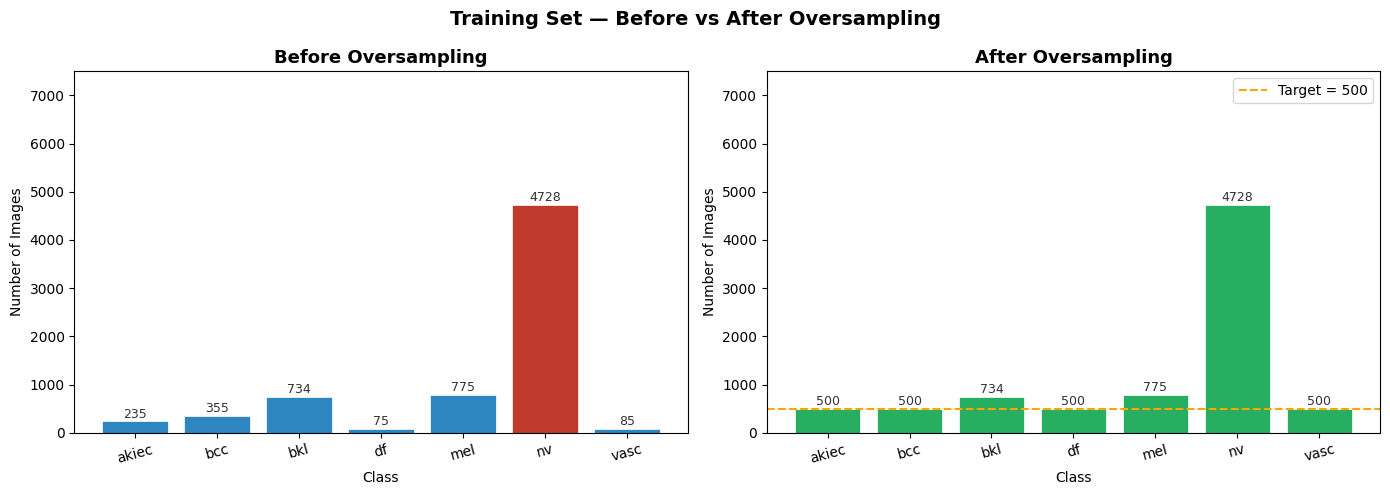

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────
before = train_df['dx'].value_counts().sort_index()
after  = train_df_balanced['dx'].value_counts().sort_index()
classes = before.index.tolist()

# ── Figure 1: Side-by-side bar chart ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Set — Before vs After Oversampling', fontsize=14, fontweight='bold')

colors_before = ['#C0392B' if c == 'nv' else '#2E86C1' for c in classes]
colors_after  = ['#27AE60' for _ in classes]

axes[0].bar(classes, before.values, color=colors_before, edgecolor='white', linewidth=0.5)
axes[0].set_title('Before Oversampling', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, 7500)
for i, v in enumerate(before.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontsize=9, color='#333333')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(classes, after.values, color=colors_after, edgecolor='white', linewidth=0.5)
axes[1].set_title('After Oversampling', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')
axes[1].set_ylim(0, 7500)
for i, v in enumerate(after.values):
    axes[1].text(i, v + 80, str(v), ha='center', fontsize=9, color='#333333')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=500, color='orange', linestyle='--', linewidth=1.5, label='Target = 500')
axes[1].legend()

plt.tight_layout()
plt.savefig('oversampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_labels = sorted(train_df['dx'].unique())

weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array(class_labels),
    y            = train_df['dx'].values
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)

print("Class | Weight")
for cls, w in zip(class_labels, weights):
    print(f"  {cls:<8} → {w:.4f}")

Device: cuda
Class | Weight
  akiec    → 4.2474
  bcc      → 2.8117
  bkl      → 1.3599
  df       → 13.3086
  mel      → 1.2879
  nv       → 0.2111
  vasc     → 11.7429


In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch

# Global — same indices across all splits
LABEL_MAP = {
    'akiec': 0,
    'bcc':   1,
    'bkl':   2,
    'df':    3,
    'mel':   4,
    'nv':    5,
    'vasc':  6
}

class SkinLesionDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        super().__init__()
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path  = self.dataframe.loc[idx, 'path']
        image     = Image.open(img_path).convert('RGB')
        label_str = self.dataframe.loc[idx, 'dx']

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(LABEL_MAP[label_str], dtype=torch.long)
        return image, label


train_dataset = SkinLesionDataset(train_df_balanced, transform=train_transforms)
val_dataset   = SkinLesionDataset(val_df,            transform=val_test_transforms)
test_dataset  = SkinLesionDataset(test_df,           transform=val_test_transforms)


image, label = train_dataset[0]
print(f"Image shape : {image.shape}")
print(f"Label       : {label}")
print(f"Label dtype : {label.dtype}")
print(f"Train size  : {len(train_dataset)}")
print(f"Val size    : {len(val_dataset)}")
print(f"Test size   : {len(test_dataset)}")

Image shape : torch.Size([3, 300, 300])
Label       : 2
Label dtype : torch.int64
Train size  : 8237
Val size    : 1512
Test size   : 1516


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Train batches : 258
Val batches   : 48
Test batches  : 48


In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
import pandas as pd
import copy

def train_model(model, model_name, train_loader, val_loader,epochs, lr, class_weights=None):
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)

    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
        print("Using weighted CrossEntropyLoss")
    else:
        criterion = nn.CrossEntropyLoss()
        print("Using standard CrossEntropyLoss")

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'val_f1':     []
    }

    best_val_loss  = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"LR: {optimizer.param_groups[0]['lr']:.8f}")

        #TRAINING
        model.train()
        train_loss = 0.0
        train_true, train_pred = [], []

        for inputs, labels in tqdm(train_loader, desc="Train"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(logits, dim=1)
            train_true.extend(labels.detach().cpu().numpy())
            train_pred.extend(preds.detach().cpu().numpy())

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_acc      = accuracy_score(train_true, train_pred)

        #VALIDATION
        model.eval()
        val_loss = 0.0
        val_true, val_pred = [], []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc="Val"):
                inputs = inputs.to(device)
                labels = labels.to(device)

                logits = model(inputs)
                loss   = criterion(logits, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(logits, dim=1)
                val_true.extend(labels.detach().cpu().numpy())
                val_pred.extend(preds.detach().cpu().numpy())

        avg_val_loss = val_loss / len(val_loader.dataset)
        val_acc      = accuracy_score(val_true, val_pred)
        val_f1       = f1_score(val_true, val_pred,
                                average='weighted', zero_division=0)

        #SCHEDULER
        scheduler.step()

        #SAVE BEST
        if avg_val_loss < best_val_loss:
            best_val_loss  = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss':             avg_val_loss,
                'val_acc':              val_acc
            }, f'best_{model_name}.pt')
            print(f"  ✓ Saved best model")

        #STORE
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"  Train → Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"  Val   → Loss: {avg_val_loss:.4f} | "
              f"Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    model.load_state_dict(best_model_wts)
    print(f"\nDone — {model_name} | Best Val Loss: {best_val_loss:.4f}")
    return model, pd.DataFrame(history)

In [ ]:
import torch.nn as nn
import matplotlib.pyplot as plt

class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # 300→150

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # 150→75

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # flatten = 128 × 1 × 1 = 128
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
cnn_model = CustomCNN(num_classes=7)

trained_cnn, cnn_history = train_model(
    model         = cnn_model,
    model_name    = "CustomCNN",
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 35,
    lr            = 0.001,
    class_weights = class_weights_tensor
)

Training: CustomCNN
Using weighted CrossEntropyLoss

Epoch 1/35 | LR: 0.00100000


Val: 100%|██████████| 48/48 [04:08<00:00,  5.18s/it]


  ✓ Saved best model
  Train → Loss: 1.5878 | Acc: 0.1325
  Val   → Loss: 2.5870 | Acc: 0.0265 | F1: 0.0166

Epoch 2/35 | LR: 0.00099799


Val: 100%|██████████| 48/48 [00:19<00:00,  2.49it/s]


  ✓ Saved best model
  Train → Loss: 1.4824 | Acc: 0.1810
  Val   → Loss: 2.4696 | Acc: 0.1653 | F1: 0.2263

Epoch 3/35 | LR: 0.00099197


...

  Train → Loss: 0.9425 | Acc: 0.4182
  Val   → Loss: 1.3273 | Acc: 0.4504 | F1: 0.5150

Epoch 34/35 | LR: 0.00000903


Val: 100%|██████████| 48/48 [00:19<00:00,  2.43it/s]


  Train → Loss: 0.9264 | Acc: 0.4141
  Val   → Loss: 1.3671 | Acc: 0.4405 | F1: 0.5039

Epoch 35/35 | LR: 0.00000301


Val: 100%|██████████| 48/48 [00:19<00:00,  2.43it/s]

  Train → Loss: 0.9468 | Acc: 0.4143
  Val   → Loss: 1.3720 | Acc: 0.4405 | F1: 0.5085

Done — CustomCNN | Best Val Loss: 1.3129


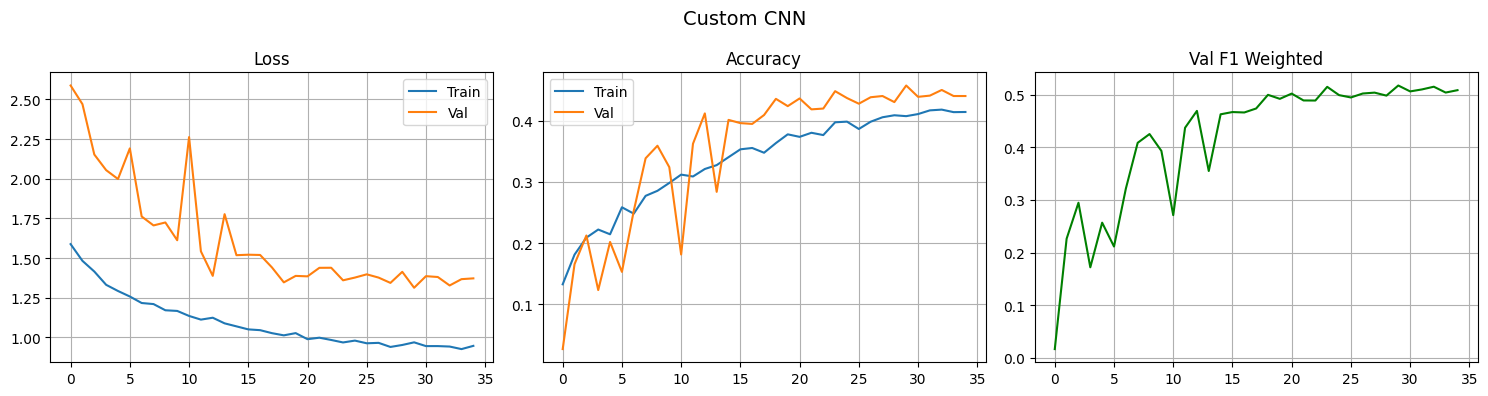

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Custom CNN', fontsize=14)

axes[0].plot(cnn_history['train_loss'], label='Train')
axes[0].plot(cnn_history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(cnn_history['train_acc'], label='Train')
axes[1].plot(cnn_history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(cnn_history['val_f1'], color='green')
axes[2].set_title('Val F1 Weighted')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt

resnet_model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)

# Freeze all
for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

num_features = resnet_model.fc.in_features   # 2048
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Linear(256, 7)
)

trainable = sum(p.numel() for p in resnet_model.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in resnet_model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 224MB/s]


Trainable: 15,491,079 / Total: 24,034,375


In [ ]:
# ── Train ─────────────────────────────────────
trained_resnet, resnet_history = train_model(
    model         = resnet_model,
    model_name    = "ResNet50",
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 35,
    lr            = 0.0001,        # smaller lr for pretrained
    class_weights = class_weights_tensor
)


Training: ResNet50
Using weighted CrossEntropyLoss

Epoch 1/35 | LR: 0.00010000


Val: 100%|██████████| 48/48 [00:26<00:00,  1.83it/s]


  ✓ Saved best model
  Train → Loss: 0.8005 | Acc: 0.3585
  Val   → Loss: 1.1429 | Acc: 0.5708 | F1: 0.6167

Epoch 2/35 | LR: 0.00009980


Val: 100%|██████████| 48/48 [00:26<00:00,  1.82it/s]


  Train → Loss: 0.4502 | Acc: 0.6359
  Val   → Loss: 1.1768 | Acc: 0.5979 | F1: 0.6365

Epoch 3/35 | LR: 0.00009920


...

  Train → Loss: 0.0532 | Acc: 0.9215
  Val   → Loss: 0.7541 | Acc: 0.8135 | F1: 0.8168

Epoch 34/35 | LR: 0.00000180


Val: 100%|██████████| 48/48 [00:28<00:00,  1.66it/s]


  Train → Loss: 0.0449 | Acc: 0.9274
  Val   → Loss: 0.7191 | Acc: 0.8142 | F1: 0.8163

Epoch 35/35 | LR: 0.00000120


Val: 100%|██████████| 48/48 [00:28<00:00,  1.67it/s]

  Train → Loss: 0.0492 | Acc: 0.9230
  Val   → Loss: 0.7248 | Acc: 0.8175 | F1: 0.8194

Done — ResNet50 | Best Val Loss: 0.6645


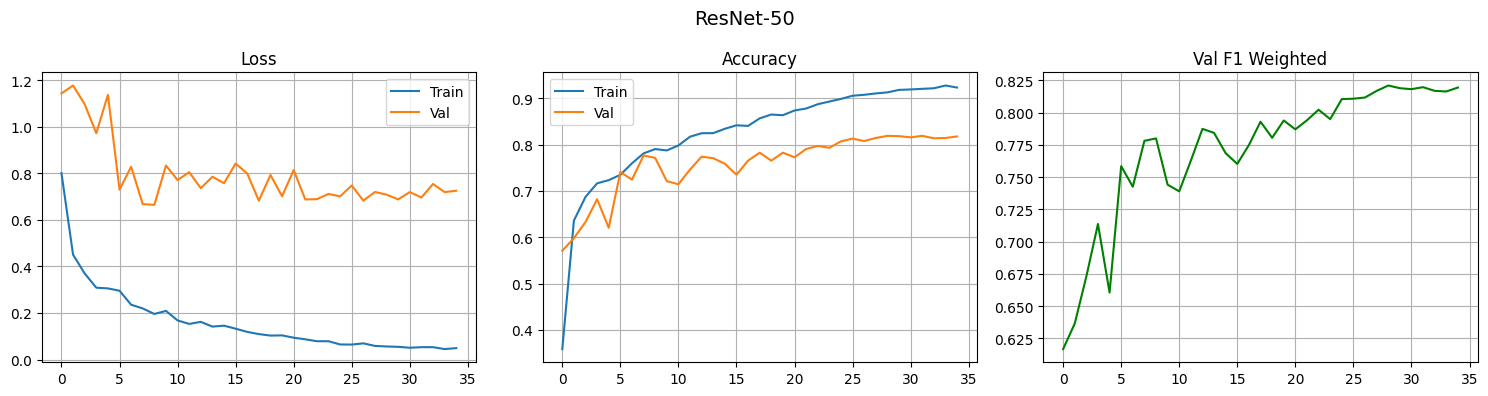

In [ ]:
# ── Plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ResNet-50', fontsize=14)

axes[0].plot(resnet_history['train_loss'], label='Train')
axes[0].plot(resnet_history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(resnet_history['train_acc'], label='Train')
axes[1].plot(resnet_history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(resnet_history['val_f1'], color='green')
axes[2].set_title('Val F1 Weighted')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt

eff_model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

# Freeze all
for param in eff_model.parameters():
    param.requires_grad = False


for param in eff_model.features[-3:].parameters():
    param.requires_grad = True

in_features = eff_model.classifier[1].in_features
eff_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Linear(256, 7)
)

trainable = sum(p.numel() for p in eff_model.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in eff_model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")





Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 185MB/s]


Trainable: 8,901,349 / Total: 11,091,503


In [ ]:
# ── Train ─────────────────────────────────────
trained_eff, eff_history = train_model(
    model         = eff_model,
    model_name    = "EfficientNet_B3",
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 35,
    lr            = 0.0001,
    class_weights = class_weights_tensor
)

Training: EfficientNet_B3
Using weighted CrossEntropyLoss

Epoch 1/35 | LR: 0.00010000


Val: 100%|██████████| 48/48 [00:26<00:00,  1.78it/s]


  ✓ Saved best model
  Train → Loss: 1.0366 | Acc: 0.2641
  Val   → Loss: 1.4554 | Acc: 0.4649 | F1: 0.5181

Epoch 2/35 | LR: 0.00009980


Val: 100%|██████████| 48/48 [00:27<00:00,  1.76it/s]


  ✓ Saved best model
  Train → Loss: 0.4703 | Acc: 0.6347
  Val   → Loss: 0.9718 | Acc: 0.6488 | F1: 0.6795

Epoch 3/35 | LR: 0.00009920


...

  Train → Loss: 0.0778 | Acc: 0.8938
  Val   → Loss: 0.7203 | Acc: 0.7996 | F1: 0.8047

Epoch 34/35 | LR: 0.00000180


Val: 100%|██████████| 48/48 [00:25<00:00,  1.87it/s]


  Train → Loss: 0.0763 | Acc: 0.8961
  Val   → Loss: 0.6877 | Acc: 0.8036 | F1: 0.8085

Epoch 35/35 | LR: 0.00000120


Val: 100%|██████████| 48/48 [00:25<00:00,  1.87it/s]

  Train → Loss: 0.0787 | Acc: 0.8926
  Val   → Loss: 0.6934 | Acc: 0.8003 | F1: 0.8053

Done — EfficientNet_B3 | Best Val Loss: 0.6437


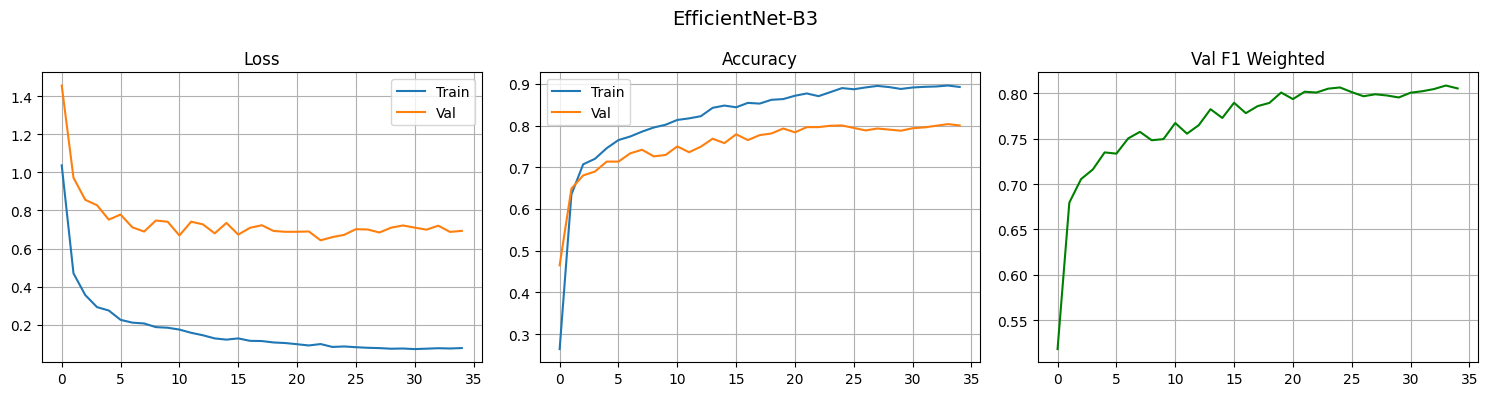

In [ ]:
# ── Plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EfficientNet-B3', fontsize=14)

axes[0].plot(eff_history['train_loss'], label='Train')
axes[0].plot(eff_history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(eff_history['train_acc'], label='Train')
axes[1].plot(eff_history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(eff_history['val_f1'], color='green')
axes[2].set_title('Val F1 Weighted')
axes[2].grid(True)

plt.tight_layout()
plt.show()

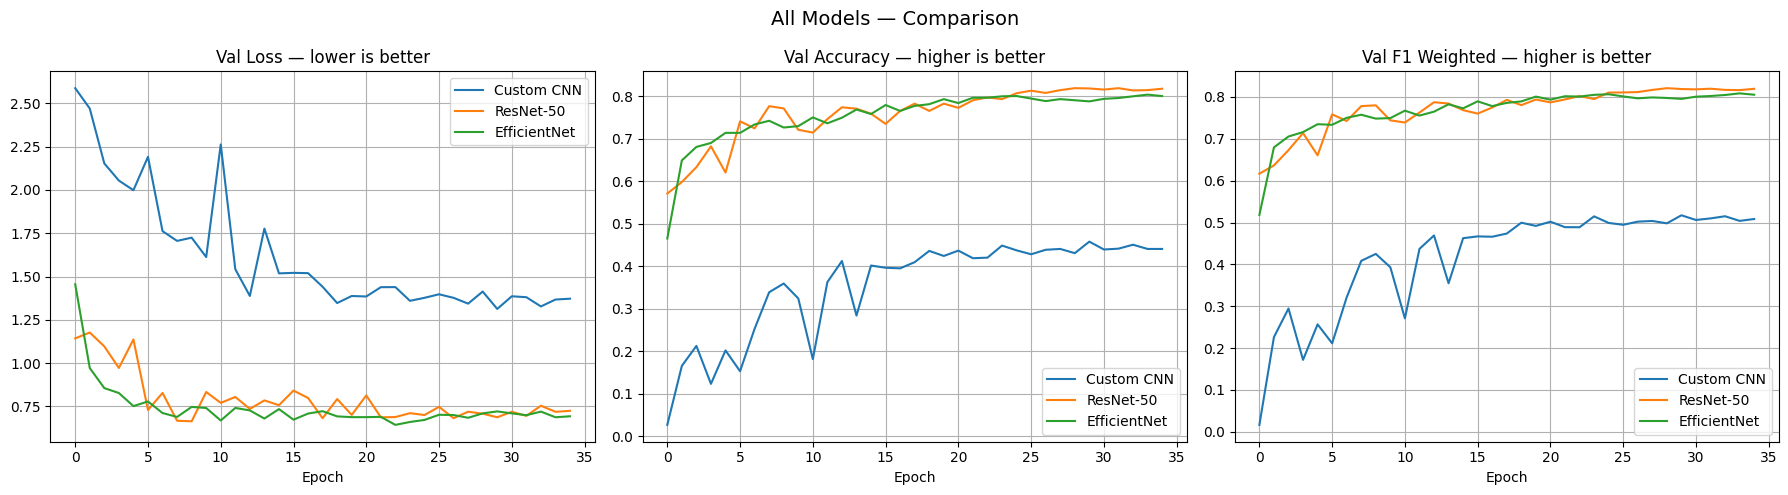

In [ ]:
import matplotlib.pyplot as plt

histories = {
    'Custom CNN':   cnn_history,
    'ResNet-50':    resnet_history,
    'EfficientNet': eff_history
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('All Models — Comparison', fontsize=14)

for name, h in histories.items():
    axes[0].plot(h['val_loss'], label=name)
    axes[1].plot(h['val_acc'],  label=name)
    axes[2].plot(h['val_f1'],   label=name)

axes[0].set_title('Val Loss — lower is better')
axes[1].set_title('Val Accuracy — higher is better')
axes[2].set_title('Val F1 Weighted — higher is better')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

  TEST RESULTS — CustomCNN
  Accuracy        : 0.4459
  Weighted F1     : 0.5118
  Macro F1        : 0.2506
  Weighted Precision : 0.7245
  Weighted Recall    : 0.4459
  ROC-AUC (OvR)   : 0.8479

Per-Class Report:
              precision    recall  f1-score   support

       akiec       0.16      0.51      0.25        51
         bcc       0.00      0.00      0.00        77
         bkl       0.49      0.11      0.18       185
          df       0.05      0.74      0.10        23
         mel       0.22      0.52      0.31       145
          nv       0.95      0.51      0.67      1019
        vasc       0.15      0.81      0.25        16

    accuracy                           0.45      1516
   macro avg       0.29      0.46      0.25      1516
weighted avg       0.72      0.45      0.51      1516



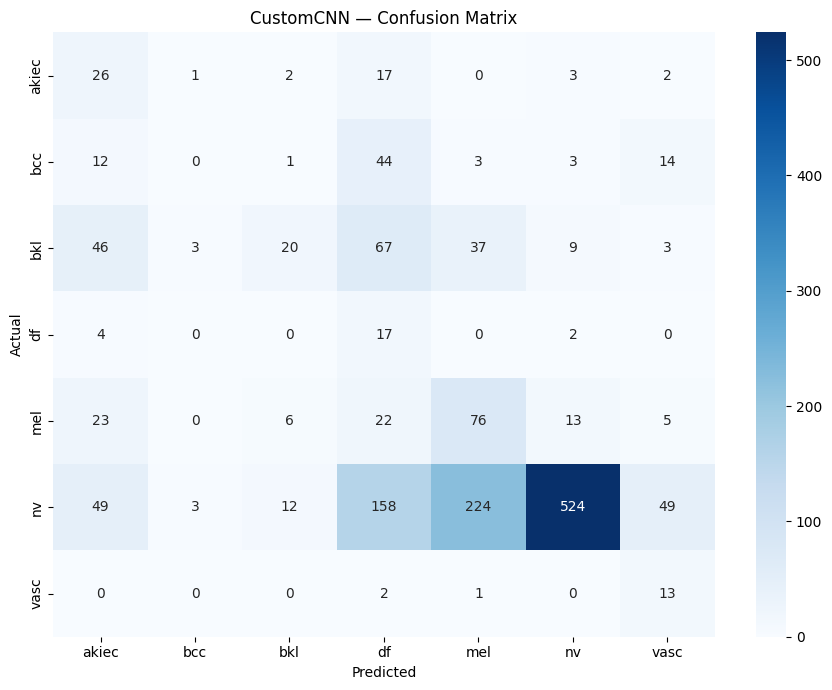

  TEST RESULTS — ResNet50
  Accuracy        : 0.7606
  Weighted F1     : 0.7793
  Macro F1        : 0.6332
  Weighted Precision : 0.8157
  Weighted Recall    : 0.7606
  ROC-AUC (OvR)   : 0.9455

Per-Class Report:
              precision    recall  f1-score   support

       akiec       0.40      0.57      0.47        51
         bcc       0.62      0.73      0.67        77
         bkl       0.69      0.59      0.64       185
          df       0.52      0.61      0.56        23
         mel       0.37      0.68      0.47       145
          nv       0.95      0.82      0.88      1019
        vasc       0.68      0.81      0.74        16

    accuracy                           0.76      1516
   macro avg       0.60      0.69      0.63      1516
weighted avg       0.82      0.76      0.78      1516



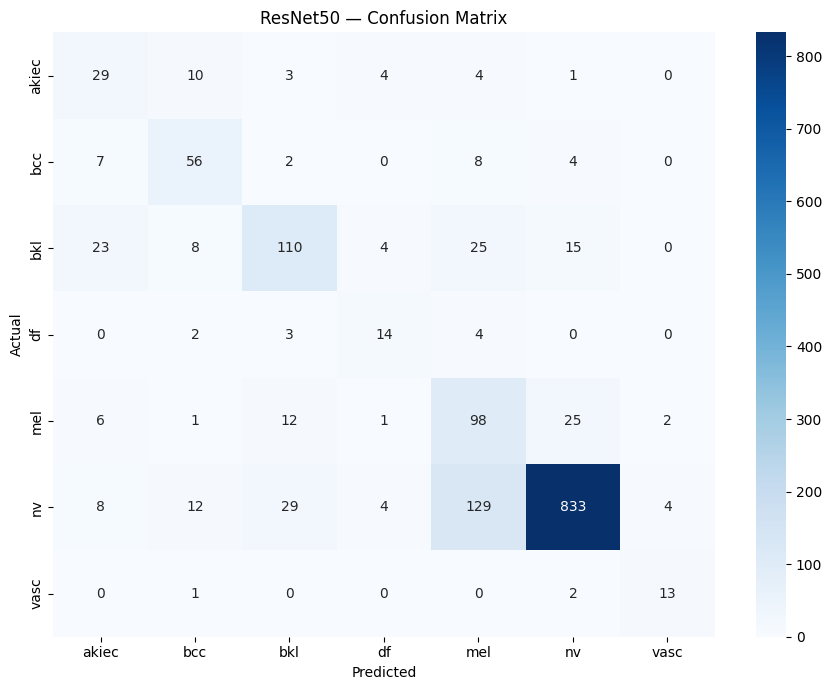

  TEST RESULTS — EfficientNet
  Accuracy        : 0.7876
  Weighted F1     : 0.8020
  Macro F1        : 0.6774
  Weighted Precision : 0.8285
  Weighted Recall    : 0.7876
  ROC-AUC (OvR)   : 0.9552

Per-Class Report:
              precision    recall  f1-score   support

       akiec       0.59      0.63      0.61        51
         bcc       0.72      0.74      0.73        77
         bkl       0.70      0.70      0.70       185
          df       0.64      0.39      0.49        23
         mel       0.37      0.64      0.47       145
          nv       0.94      0.84      0.89      1019
        vasc       0.79      0.94      0.86        16

    accuracy                           0.79      1516
   macro avg       0.68      0.70      0.68      1516
weighted avg       0.83      0.79      0.80      1516



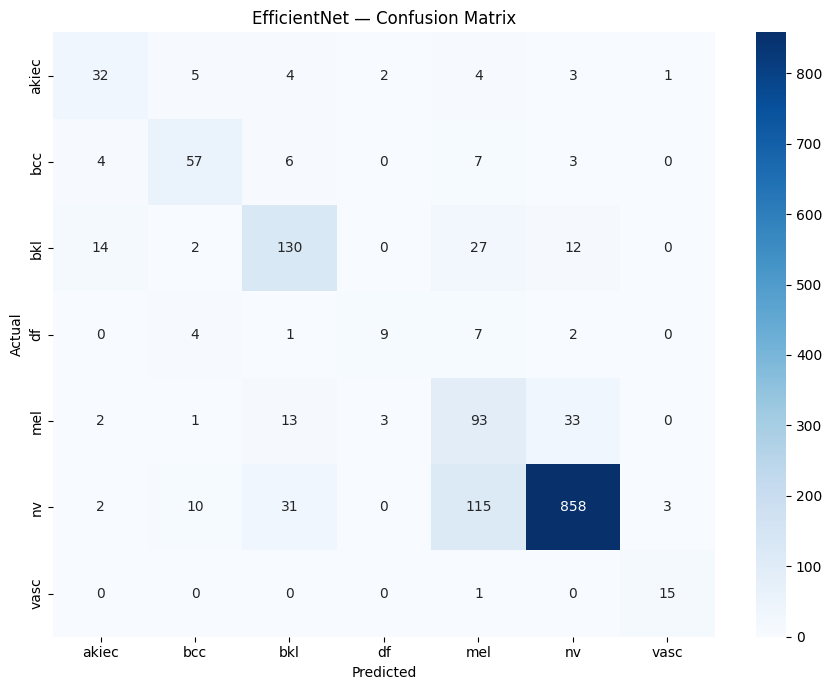

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

def evaluate_model(model, test_loader, model_name, device):

    model.eval()
    y_true  = []
    y_pred  = []
    y_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(probs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_probs = np.array(y_probs)

    # ── Overall Metrics ──────────────────────────────────────
    accuracy   = accuracy_score(y_true, y_pred)
    f1_weighted = f1_score(y_true, y_pred,average='weighted', zero_division=0)
    f1_macro   = f1_score(y_true, y_pred,average='macro', zero_division=0)
    precision  = precision_score(y_true, y_pred,average='weighted', zero_division=0)
    recall     = recall_score(y_true, y_pred,average='weighted', zero_division=0)
    roc_auc    = roc_auc_score(y_true, y_probs,multi_class='ovr', average='macro')


    print(f"  TEST RESULTS — {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy        : {accuracy:.4f}")
    print(f"  Weighted F1     : {f1_weighted:.4f}")
    print(f"  Macro F1        : {f1_macro:.4f}")
    print(f"  Weighted Precision : {precision:.4f}")
    print(f"  Weighted Recall    : {recall:.4f}")
    print(f"  ROC-AUC (OvR)   : {roc_auc:.4f}")
    print(f"{'='*55}")

    # ── Per Class Breakdown ───────────────────────────────────
    print(f"\nPer-Class Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        zero_division=0
    ))

    # ── Confusion Matrix ──────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm,
        annot      = True,
        fmt        = 'd',
        cmap       = 'Blues',
        xticklabels = class_names,
        yticklabels = class_names
    )
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {
        'accuracy':    accuracy,
        'f1_weighted': f1_weighted,
        'f1_macro':    f1_macro,
        'precision':   precision,
        'recall':      recall,
        'roc_auc':     roc_auc
    }

# ── Evaluate All Three ────────────────────────────────────────
cnn_metrics    = evaluate_model(trained_cnn,    test_loader,
                                "CustomCNN",    device)
resnet_metrics = evaluate_model(trained_resnet, test_loader,
                                "ResNet50",     device)
eff_metrics    = evaluate_model(trained_eff,    test_loader,
                                "EfficientNet", device)

In [ ]:
# Compare all three models side by side
print(f"\n{'='*65}")
print(f"  FINAL MODEL COMPARISON")
print(f"{'='*65}")
print(f"  {'Metric':<20} {'CNN':>10} {'ResNet':>10} {'EfficientNet':>14}")
print(f"  {'-'*60}")

metrics_to_show = [
    ('Accuracy',    'accuracy'),
    ('F1 Weighted', 'f1_weighted'),
    ('F1 Macro',    'f1_macro'),
    ('Precision',   'precision'),
    ('Recall',      'recall'),
    ('ROC-AUC',     'roc_auc')
]

for label, key in metrics_to_show:
    cnn_val = cnn_metrics[key]
    res_val = resnet_metrics[key]
    eff_val = eff_metrics[key]
    print(f"  {label:<20} {cnn_val:>10.4f} {res_val:>10.4f} {eff_val:>14.4f}")

print(f"{'='*65}")


  FINAL MODEL COMPARISON
  Metric                      CNN     ResNet   EfficientNet
  ------------------------------------------------------------
  Accuracy                 0.4459     0.7606         0.7876
  F1 Weighted              0.5118     0.7793         0.8020
  F1 Macro                 0.2506     0.6332         0.6774
  Precision                0.7245     0.8157         0.8285
  Recall                   0.4459     0.7606         0.7876
  ROC-AUC                  0.8479     0.9455         0.9552


Device: cuda
All three models loaded successfully.
Sample index : 1211
True label   : nv (class 5)


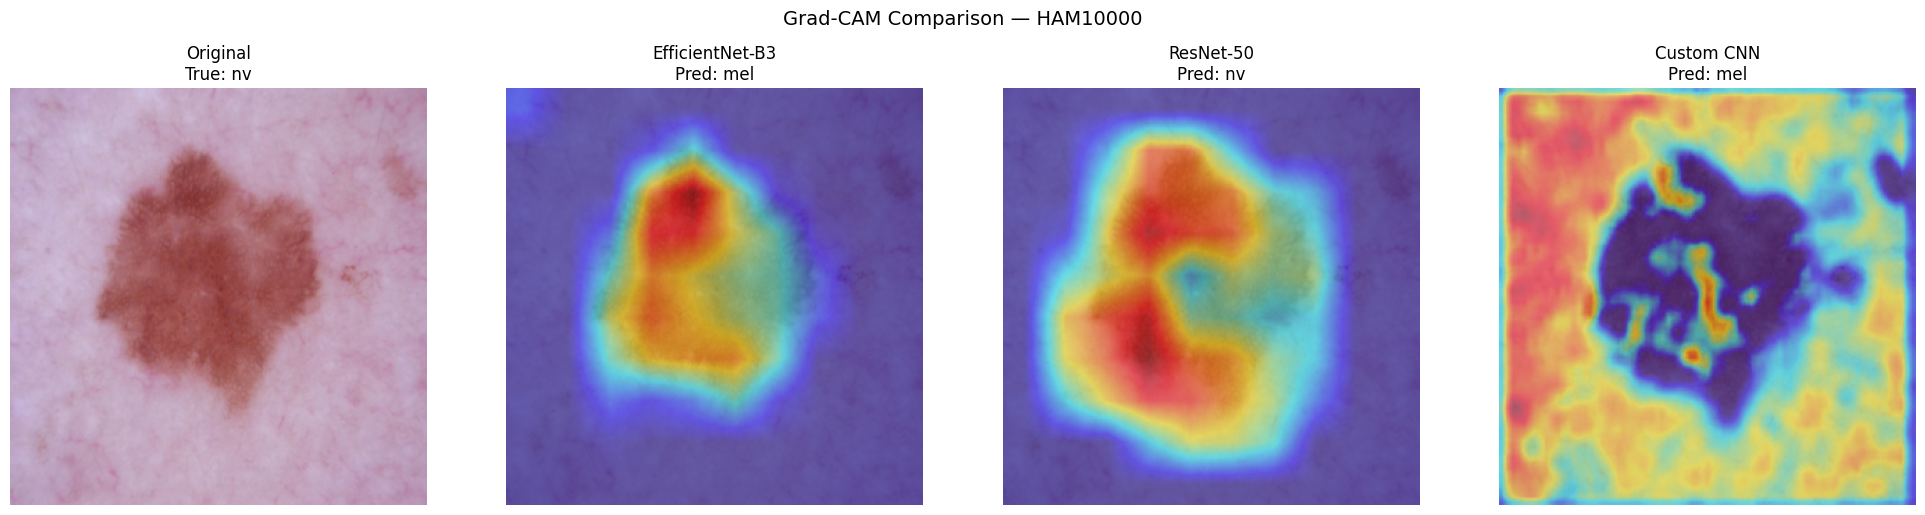


Predictions:
  EfficientNet-B3 : mel
  ResNet-50       : nv
  Custom CNN      : mel


In [ ]:
# ─────────────────────────────────────────────────────────────
# GRAD-CAM — HAM10000  |  All Three Models
# Run this after your training cells have completed
# ─────────────────────────────────────────────────────────────

import os
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms


def run_multiple(n=4, class_filter=None):
    """
    Visualise Grad-CAM on n random test samples.
    class_filter : int — if set, only picks samples of that class
                   e.g. class_filter=4 for melanoma only
    """
    if class_filter is not None:
        indices = [i for i in range(len(test_dataset))
                   if test_dataset[i][1].item() == class_filter]
        if len(indices) == 0:
            print(f"No samples found for class {class_filter}")
            return
        chosen = random.sample(indices, min(n, len(indices)))
    else:
        chosen = random.sample(range(len(test_dataset)), n)

    for idx in chosen:
        img_tensor, lbl = test_dataset[idx]
        img_tensor = img_tensor.unsqueeze(0)
        print(f"\nIndex {idx} | True: {LABEL_NAMES[lbl.item()]}")
        visualize_all_three(
            eff_model, resnet_model, cnn_model,
            img_tensor, true_label=lbl.item()
        )

# Example: 3 random melanoma samples
# run_multiple(n=3, class_filter=4)

# Example: 5 random samples from any class
# run_multiple(n=5)

In [ ]:
LABEL_MAP = {
    'akiec': 0,
    'bcc':   1,
    'bkl':   2,
    'df':    3,
    'mel':   4,
    'nv':    5,
    'vasc':  6
}

LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}   # {0: 'akiec', ...}

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # 300→150
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),              # 150→75
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_resnet():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Linear(256, 7)
    )
    return model


def build_efficientnet():
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[-3:].parameters():
        param.requires_grad = True
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Linear(256, 7)
    )
    return model



In [ ]:
eff_model    = build_efficientnet().to(DEVICE)
resnet_model = build_resnet().to(DEVICE)
cnn_model    = CustomCNN(num_classes=7).to(DEVICE)

checkpoint_eff    = torch.load('/content/best_EfficientNet_B3.pt', map_location=DEVICE)
checkpoint_resnet = torch.load('/content/best_ResNet50.pt',        map_location=DEVICE)
checkpoint_cnn    = torch.load('/content/best_CustomCNN.pt',       map_location=DEVICE)

eff_model.load_state_dict(checkpoint_eff['model_state_dict'])
resnet_model.load_state_dict(checkpoint_resnet['model_state_dict'])
cnn_model.load_state_dict(checkpoint_cnn['model_state_dict'])

eff_model.eval()
resnet_model.eval()
cnn_model.eval()

print("All three models loaded successfully.")


All three models loaded successfully.


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        """
        input_tensor : (1, 3, H, W) on same device as model
        class_idx    : int — uses predicted class if None
        Returns      : (cam H×W in [0,1], predicted class_idx)
        """
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)        # (1, C, 1, 1)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True) # (1, 1, H, W)
        cam     = F.relu(cam).squeeze().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


In [ ]:
EFF_TARGET    = eff_model.features[-1][0]
RESNET_TARGET = resnet_model.layer4[-1].conv3
CNN_TARGET    = cnn_model.features[8]

In [ ]:
def overlay_gradcam(image_tensor, cam, alpha=0.5):
    """
    image_tensor : (1, 3, H, W) normalised tensor
    cam          : numpy array in [0, 1] from GradCAM.generate()
    Returns      : numpy (H, W, 3) in [0, 1] ready for imshow
    """
    img = image_tensor.squeeze().cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    h, w        = img.shape[:2]
    cam_resized = cv2.resize(cam, (w, h))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = heatmap[:, :, ::-1] / 255.0   # BGR → RGB, normalise

    overlay = alpha * heatmap + (1 - alpha) * img
    return np.clip(overlay, 0, 1)

In [ ]:
def visualize_all_three(eff_model, resnet_model, cnn_model,
                        image_tensor, true_label=None):
    """
    Runs Grad-CAM for all three models and plots:
    Original | EfficientNet-B3 | ResNet-50 | Custom CNN

    Returns: (pred_eff, pred_resnet, pred_cnn)
    """
    device       = next(eff_model.parameters()).device
    image_tensor = image_tensor.to(device)

    # Instantiate Grad-CAM for each model
    gradcam_eff    = GradCAM(eff_model,    EFF_TARGET)
    gradcam_resnet = GradCAM(resnet_model, RESNET_TARGET)
    gradcam_cnn    = GradCAM(cnn_model,    CNN_TARGET)

    # Generate CAMs
    cam_eff,    pred_eff    = gradcam_eff.generate(image_tensor)
    cam_resnet, pred_resnet = gradcam_resnet.generate(image_tensor)
    cam_cnn,    pred_cnn    = gradcam_cnn.generate(image_tensor)

    # Overlay heatmaps
    overlay_eff    = overlay_gradcam(image_tensor, cam_eff)
    overlay_resnet = overlay_gradcam(image_tensor, cam_resnet)
    overlay_cnn    = overlay_gradcam(image_tensor, cam_cnn)

    # Denormalise original for display
    orig = (image_tensor.squeeze().cpu() * IMAGENET_STD + IMAGENET_MEAN)
    orig = orig.permute(1, 2, 0).numpy()
    orig = np.clip(orig, 0, 1)

    true_str = f"True: {LABEL_NAMES.get(true_label, '?')}" if true_label is not None else ""

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(orig)
    axes[0].set_title(f"Original\n{true_str}", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(overlay_eff)
    axes[1].set_title(f"EfficientNet-B3\nPred: {LABEL_NAMES[pred_eff]}", fontsize=12)
    axes[1].axis("off")

    axes[2].imshow(overlay_resnet)
    axes[2].set_title(f"ResNet-50\nPred: {LABEL_NAMES[pred_resnet]}", fontsize=12)
    axes[2].axis("off")

    axes[3].imshow(overlay_cnn)
    axes[3].set_title(f"Custom CNN\nPred: {LABEL_NAMES[pred_cnn]}", fontsize=12)
    axes[3].axis("off")

    plt.suptitle("Grad-CAM Comparison — HAM10000", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return pred_eff, pred_resnet, pred_cnn


Sample index : 1476
True label   : akiec (class 0)


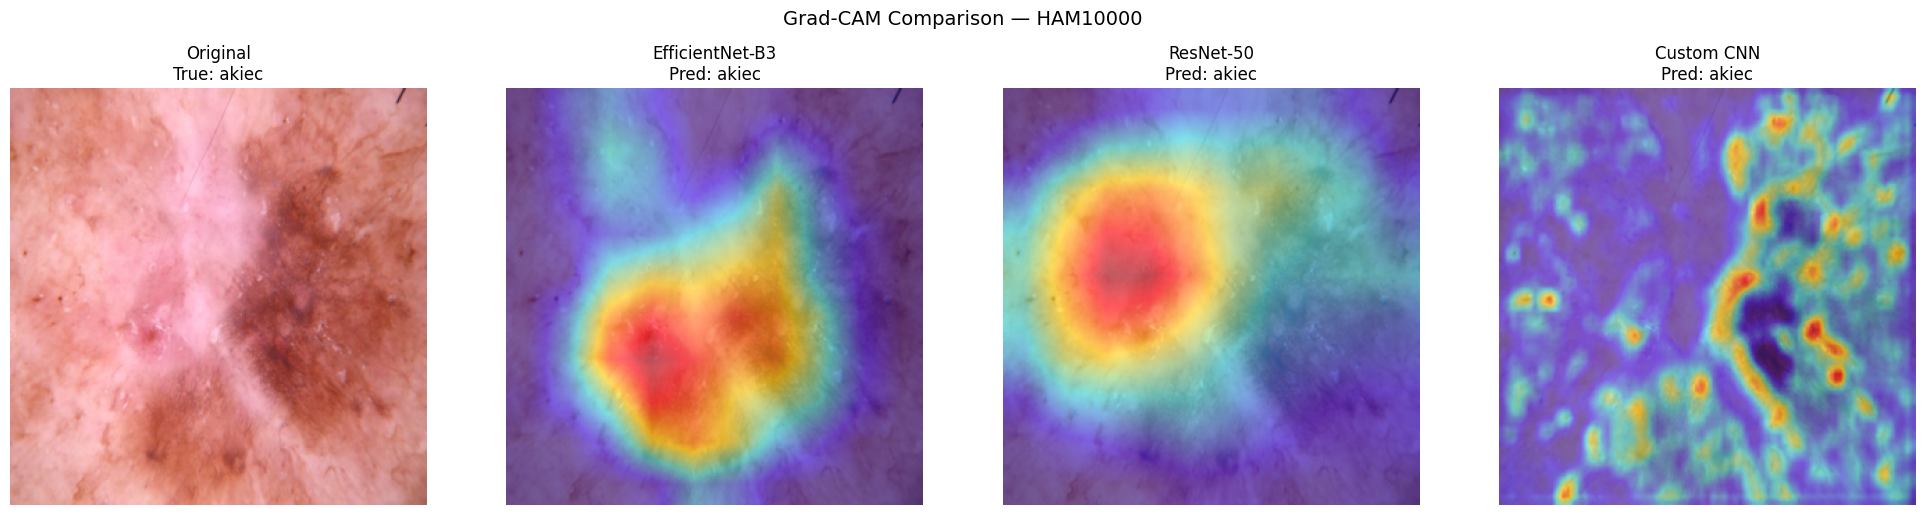


Predictions:
  EfficientNet-B3 : akiec
  ResNet-50       : akiec
  Custom CNN      : akiec


In [ ]:
idx = random.randint(0, len(test_dataset) - 1)
image_tensor, true_label = test_dataset[idx]
image_tensor = image_tensor.unsqueeze(0)   # (1, 3, 300, 300)

print(f"Sample index : {idx}")
print(f"True label   : {LABEL_NAMES[true_label.item()]} (class {true_label.item()})")

pred_eff, pred_resnet, pred_cnn = visualize_all_three(
    eff_model, resnet_model, cnn_model,
    image_tensor, true_label=true_label.item()
)

print(f"\nPredictions:")
print(f"  EfficientNet-B3 : {LABEL_NAMES[pred_eff]}")
print(f"  ResNet-50       : {LABEL_NAMES[pred_resnet]}")
print(f"  Custom CNN      : {LABEL_NAMES[pred_cnn]}")



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
N_CLASSES   = len(CLASS_NAMES)

# Colours per class — consistent across all three model plots
CLASS_COLORS = ['#E74C3C', '#8E44AD', '#2980B9', '#27AE60',
                '#F39C12', '#16A085', '#2C3E50']


In [ ]:
def get_probs_and_labels(model, loader, device):
    """
    Returns:
        y_true  : (N,)   integer class labels
        y_probs : (N, 7) softmax probabilities
    """
    model.eval()
    y_true, y_probs = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_probs.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_probs)


In [ ]:
def plot_roc(y_true, y_probs, model_name, ax):
    """
    Plots per-class ROC curves + macro-average on a given axes.
    """
    y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))

    fpr, tpr, roc_auc = {}, {}, {}

    # Per-class curves
    for i in range(N_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc[i]        = auc(fpr[i], tpr[i])

    # Macro-average
    all_fpr         = np.unique(np.concatenate([fpr[i] for i in range(N_CLASSES)]))
    mean_tpr        = np.zeros_like(all_fpr)
    for i in range(N_CLASSES):
        mean_tpr   += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr       /= N_CLASSES
    roc_auc['macro'] = auc(all_fpr, mean_tpr)

    # Plot per-class
    for i in range(N_CLASSES):
        ax.plot(fpr[i], tpr[i],
                color=CLASS_COLORS[i], lw=1.5,
                label=f"{CLASS_NAMES[i]}  (AUC = {roc_auc[i]:.2f})")

    # Plot macro-average
    ax.plot(all_fpr, mean_tpr,
            color='black', lw=2.5, linestyle='--',
            label=f"Macro avg  (AUC = {roc_auc['macro']:.2f})")

    # Diagonal reference
    ax.plot([0, 1], [0, 1], color='#AAAAAA', lw=1, linestyle=':')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

    return roc_auc


In [ ]:
print("Collecting probabilities...")
y_true_cnn,    y_probs_cnn    = get_probs_and_labels(cnn_model,    test_loader, DEVICE)
y_true_resnet, y_probs_resnet = get_probs_and_labels(resnet_model, test_loader, DEVICE)
y_true_eff,    y_probs_eff    = get_probs_and_labels(eff_model,    test_loader, DEVICE)
print("Done.")

Done.


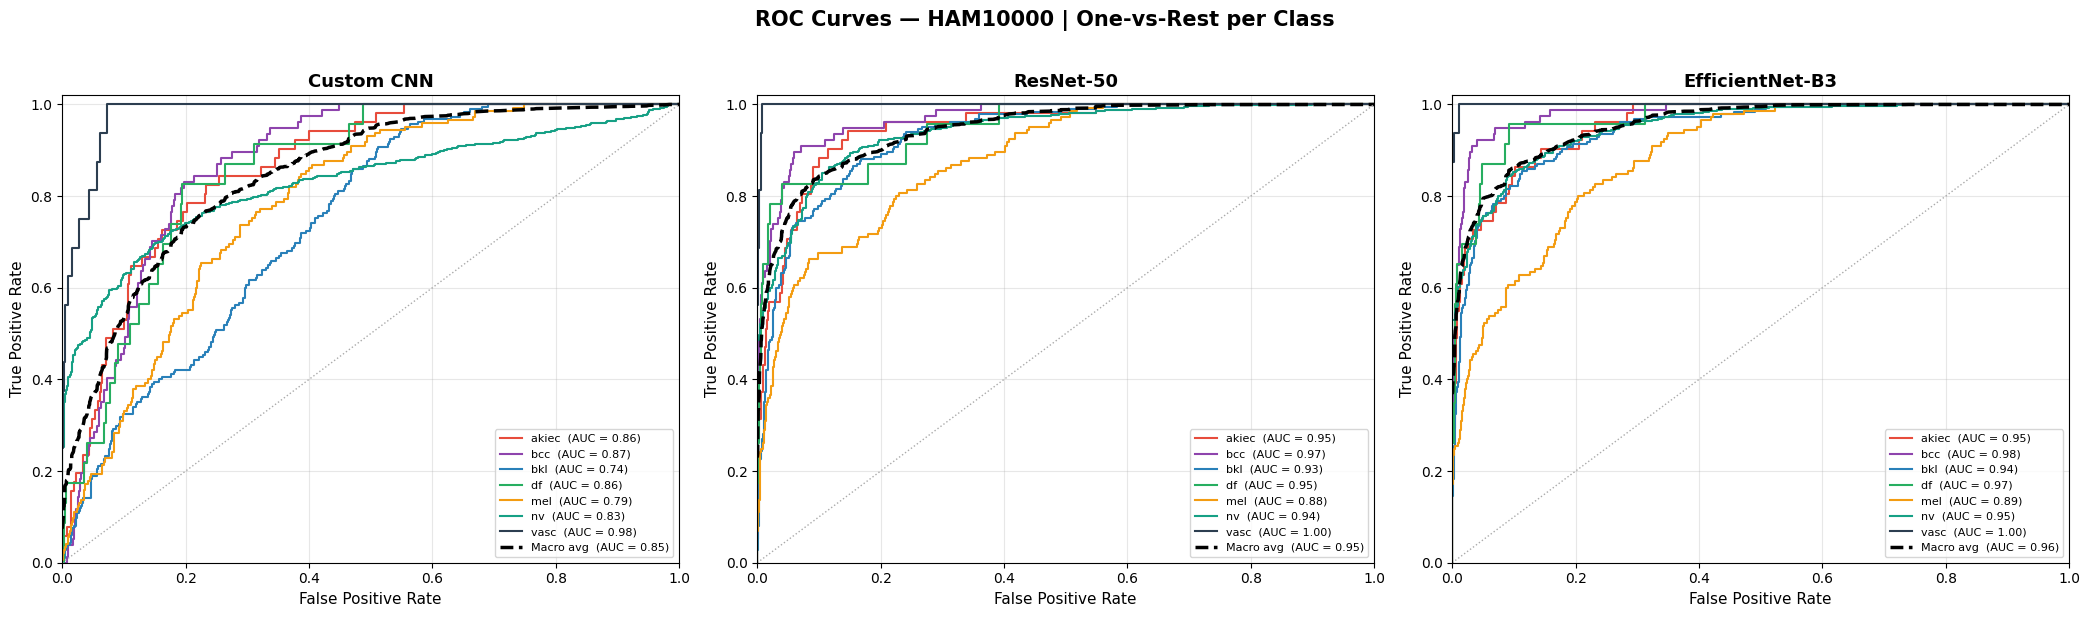

Saved → roc_curves_all_models.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('ROC Curves — HAM10000 | One-vs-Rest per Class',
             fontsize=15, fontweight='bold', y=1.02)

auc_cnn    = plot_roc(y_true_cnn,    y_probs_cnn,    "Custom CNN",      axes[0])
auc_resnet = plot_roc(y_true_resnet, y_probs_resnet, "ResNet-50",       axes[1])
auc_eff    = plot_roc(y_true_eff,    y_probs_eff,    "EfficientNet-B3", axes[2])

plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → roc_curves_all_models.png")

In [ ]:
print(f"\n{'='*55}")
print(f"  ROC-AUC SUMMARY")
print(f"{'='*55}")
print(f"  {'Class':<10} {'CNN':>10} {'ResNet':>10} {'EffNet':>10}")
print(f"  {'-'*45}")

for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:<10} {auc_cnn[i]:>10.4f} {auc_resnet[i]:>10.4f} {auc_eff[i]:>10.4f}")

print(f"  {'-'*45}")
print(f"  {'Macro avg':<10} {auc_cnn['macro']:>10.4f} "
      f"{auc_resnet['macro']:>10.4f} {auc_eff['macro']:>10.4f}")
print(f"{'='*55}")


  ROC-AUC SUMMARY
  Class             CNN     ResNet     EffNet
  ---------------------------------------------
  akiec          0.8628     0.9482     0.9548
  bcc            0.8729     0.9689     0.9816
  bkl            0.7441     0.9326     0.9439
  df             0.8578     0.9463     0.9687
  mel            0.7869     0.8831     0.8873
  nv             0.8291     0.9414     0.9509
  vasc           0.9814     0.9983     0.9992
  ---------------------------------------------
  Macro avg      0.8483     0.9459     0.9555


In [ ]:
from google.colab import files
files.download('best_ResNet50.pt')
files.download('best_EfficientNet_B3.pt')

FileNotFoundError: Cannot find file: best_ResNet50.pt

In [ ]:
import json

# Derived directly from your LABEL_MAP — order preserved by value
class_names = sorted(LABEL_MAP, key=LABEL_MAP.get)
# gives → ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print(class_names)  # verify order before downloading

from google.colab import files
files.download('class_names.json')

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>